Epoch 0 Loss 0.14520660042762756
Epoch 300 Loss 0.030957309529185295
Epoch 600 Loss 0.02265956811606884
Epoch 900 Loss 0.019782181829214096
Epoch 1200 Loss 0.017625348642468452
Epoch 1500 Loss 0.016278047114610672
Epoch 1800 Loss 0.015634972602128983
Epoch 2100 Loss 0.014691106975078583
Epoch 2400 Loss 0.013984491117298603
Epoch 2700 Loss 0.013626409694552422

===== 欠損点予測 =====

(39,0) 予測=0.4467 真値=0.0000 誤差=0.4467
(54,0) 予測=0.5186 真値=0.0000 誤差=0.5186
(80,0) 予測=0.4837 真値=0.0000 誤差=0.4837
(86,0) 予測=0.4791 真値=0.0000 誤差=0.4791
(114,0) 予測=0.4601 真値=0.0000 誤差=0.4601
(144,0) 予測=0.4468 真値=0.0000 誤差=0.4468
(195,0) 予測=0.3179 真値=0.0000 誤差=0.3179
(212,0) 予測=0.5066 真値=0.0000 誤差=0.5066
(225,0) 予測=0.5518 真値=0.0000 誤差=0.5518
(251,0) 予測=0.5566 真値=0.0000 誤差=0.5566
(253,0) 予測=0.5562 真値=0.0000 誤差=0.5562
(5,1) 予測=0.5751 真値=0.4353 誤差=0.1398
(17,1) 予測=0.5385 真値=0.4157 誤差=0.1228
(18,1) 予測=0.5401 真値=0.4157 誤差=0.1244
(21,1) 予測=0.5416 真値=0.4275 誤差=0.1141
(24,1) 予測=0.5379 真値=0.4118 誤差=0.1261
(79,1) 予測=0.4836 真値=

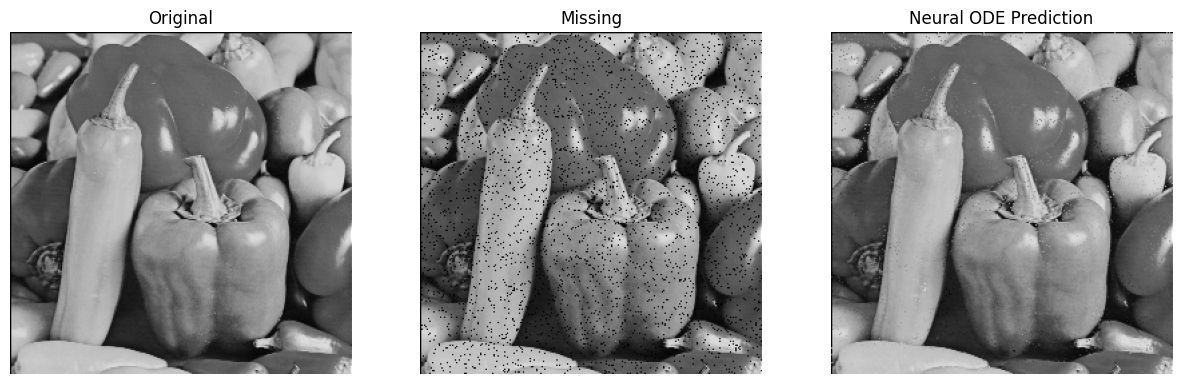

In [3]:
# ============================================
# Neural ODE 画像欠損補間
# 「既知画素は保持し、欠損画素だけ補間」
# ============================================

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchdiffeq import odeint

# ============================================
# 画像読み込み
# ============================================

# 白黒画像として読み込み
img = Image.open("Images/Peppers.png").convert("L")

# 解像度
img = img.resize((256,256))

# numpy化
img_array = np.array(img).astype(np.float32)

# 画素値（色の数値：0~255の値）を0〜1正規化
img_array = img_array / 255.0

# ============================================
# 座標作成
# ============================================

height, width = img_array.shape

# 座標正規化（重要）
x = np.linspace(-1,1,width)
y = np.linspace(-1,1,height)

X, Y = np.meshgrid(x, y)

# ============================================
# 欠損作成
# ============================================

mask = np.ones(img_array.shape, dtype=bool)


# 欠損させるピクセル(座標ランダム版)

np.random.seed(42)

num_missing = int(height * width * 0.05)

indices = np.random.choice(
    height * width,
    num_missing,
    replace=False
)

missing_points = [
    (idx // width, idx % width)
    for idx in indices
]
"""
#ブロック欠損版
missing_points = []

for i in range(100,156):
    for j in range(100,156):
        missing_points.append((i,j))
# 欠損させるピクセル(座標指定版)

missing_points = [

    (20,20),
    (20,21),
    (20,22),

    (21,20),
    (21,21),
    (21,22),

    (22,20),
    (22,21),
    (22,22),

    (40,40),
    (41,41),
    (42,42)

]
"""
# 欠損化
for i,j in missing_points:

    mask[i,j] = False #欠損にしたい座標(i,j)だけをFalseにする

# 欠損画像
img_missing = img_array.copy() #元データを書き換えないためにコピーを作る

img_missing[~mask] = np.nan #欠損指定した座標だけNaNに置き換える

# ============================================
# 学習データ作成
# ============================================

coords = np.stack(
    [X.flatten(), Y.flatten()],
    axis=1
)

targets = img_array.flatten()

mask_flat = mask.flatten()

# 観測点のみ学習
coords_train = coords[mask_flat]

targets_train = targets[mask_flat]

# Tensor化
coords_tensor = torch.tensor(
    coords_train,
    dtype=torch.float32
)

targets_tensor = torch.tensor(
    targets_train,
    dtype=torch.float32
).view(-1,1)

# ============================================
# ODE Function
# ============================================

class ODEFunc(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(2,128),
            nn.Tanh(),

            nn.Linear(128,128),
            nn.Tanh(),

            nn.Linear(128,128),
            nn.Tanh(),

            nn.Linear(128,2)

        )

    def forward(self, t, h):

        return self.net(h)

# ============================================
# Neural ODE
# ============================================

class NeuralODEModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.odefunc = ODEFunc()

        self.output_layer = nn.Linear(2,1)

    def forward(self, x_input):

        h0 = x_input

        t = torch.tensor([0,1]).float()

        out = odeint(
            self.odefunc,
            h0,
            t,
            method='rk4'
        )

        h_final = out[-1]

        z_pred = self.output_layer(h_final)

        return z_pred

# ============================================
# モデル
# ============================================

model = NeuralODEModel()

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# ============================================
# 学習
# ============================================

epochs = 3000

for epoch in range(epochs):

    optimizer.zero_grad()

    pred = model(coords_tensor)

    loss = criterion(
        pred,
        targets_tensor
    )

    loss.backward()

    optimizer.step()

    if epoch % 300 == 0:

        print(
            f"Epoch {epoch} "
            f"Loss {loss.item()}"
        )

# ============================================
# 全画素予測
# ============================================

all_coords_tensor = torch.tensor(
    coords,
    dtype=torch.float32
)

with torch.no_grad():

    img_pred = model(
        all_coords_tensor
    ).numpy()

img_pred = img_pred.reshape(
    height,
    width
)

# ============================================
# 欠損部分だけ補間
# ============================================

# 既知画素はそのまま
final_img = img_missing.copy()

# 欠損部分だけNeural ODE予測値を代入
final_img[~mask] = img_pred[~mask]

# ============================================
# 欠損点精度表示
# ============================================

print("\n===== 欠損点予測 =====\n")

missing_y, missing_x = np.where(~mask)

for idx in range(len(missing_x)):

    x_val = missing_x[idx]
    y_val = missing_y[idx]

    pred_val = final_img[y_val, x_val]

    true_val = img_array[y_val, x_val]

    error = abs(pred_val - true_val)

    print(
        f"({x_val},{y_val}) "
        f"予測={pred_val:.4f} "
        f"真値={true_val:.4f} "
        f"誤差={error:.4f}"
    )

# ============================================
# 欠損点MSE
# ============================================

missing_mse = np.mean(

    (
        img_array[~mask]
        -
        final_img[~mask]

    )**2
)

print("\n==============================")
print("Missing MSE :", missing_mse)
print("==============================")

# ============================================
# 可視化
# ============================================

fig, ax = plt.subplots(1,3, figsize=(15,5))

# 元画像
ax[0].imshow(
    img_array,
    cmap='gray'
)

ax[0].set_title("Original")

# 欠損画像
ax[1].imshow(
    np.nan_to_num(img_missing, nan=0),
    cmap='gray'
)

ax[1].set_title("Missing")

# 補間結果
ax[2].imshow(
    final_img,
    cmap='gray'
)

ax[2].set_title("Neural ODE Prediction")

# 軸OFF
for i in range(3):

    ax[i].axis("off")

plt.show()